# LLM Training as Large-scale Optimization

So far we have already discussed stochastic optimization problem:
```{math}
:label: eq-stoc-opt-chap4
\min_{\vw}\ \ell(\vw) := \EE_{\xi\sim\mathcal{D}}[\ell(\vw,\xi)]
```
where $\mathcal{D}$ is the data distribution. Note that for neural network training, we usually collect a set of training data $\{\xi_i\}_{i=1,2,...,n}$ and optimize for the training loss
```{math}
:label: eq-stoc-opt-finite-sum-chap4
\min_{\vw}\ \ell(\vw) := \frac{1}{n}\sum_{i=1}^{n}\ell(\vw, \xi_i)
```
which is also know as the finite sum setting of the stochastic optimization.

The basic stochastic gradient descent (SGD) scheme (see also [add ref here to chap 2]) is to simply sample a random index $i_t$ at iteration $t$, and update (for simplicity, we denote $\xi_{t}:=\xi_{i_t}$)
```{math}
:label: eq-SGD-chap4
\vw^{t+1}\leftarrow \vw^{t} - \eta_t\nabla \ell(\vw^t, \xi_t).
```

As discussed in Chapter 2, stochastic methods such as SGD only has a noisy estimate of the true gradients, thus suffering from the inexactness of the noise. This motivates the mini-batch version of the SGD algorithm: at each iteration, we sample a mini-batch of the data samples $\{i_{1,t},i_{2,t},...,i_{B,t}\}$ where $B$ is the so-called batch size, and update
```{math}
:label: eq-minibatch-SGD-chap4
\vw^{t+1}\leftarrow \vw^{t} - \frac{\eta_t}{B}\sum_{j=1}^{B}\nabla \ell(\vw^t, \xi_{i_{j,t}}).
```
Intuitively, the larger the batch size $B$ is, the closer the average of stochastic gradient is to the true gradient $\nabla \ell(\vw^t)$. 

Below we have a simple example on training a simple two layer neural network for classifying MNIST hand-written digits $0$ and $1$. We just test the effect of different batch sizes and record the distance of the stochastic gradient toward the true gradient.

Batch size: 4, Avg distance to full grad: 2.307725
Batch size: 8, Avg distance to full grad: 1.388254
Batch size: 16, Avg distance to full grad: 0.961190
Batch size: 32, Avg distance to full grad: 1.106750
Batch size: 64, Avg distance to full grad: 0.771912
Batch size: 128, Avg distance to full grad: 0.791104
Batch size: 256, Avg distance to full grad: 0.989365
Batch size: 512, Avg distance to full grad: 0.835109


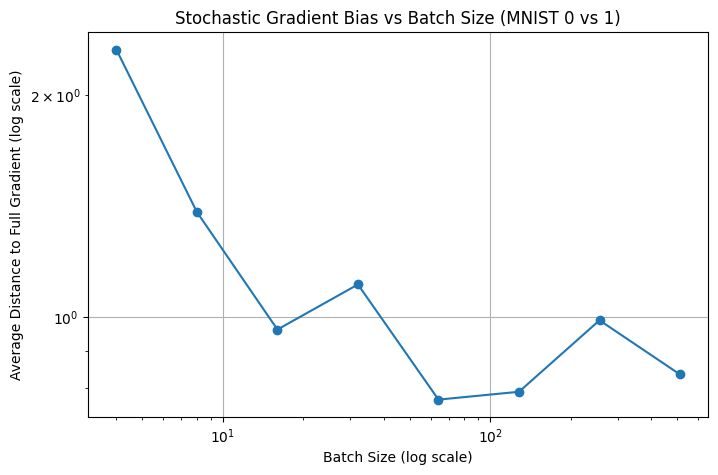

In [3]:
import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
import numpy as np

# Binary classification: digits 0 vs 1
def get_mnist_binary():
    transform = transforms.ToTensor()
    train_dataset = torchvision.datasets.MNIST(root='./data', train=True, transform=transform, download=True)
    indices = [i for i, (_, y) in enumerate(train_dataset) if y in [0, 1]]
    binary_subset = Subset(train_dataset, indices)
    return binary_subset

class TwoLayerNN(nn.Module):
    def __init__(self, input_size=28*28, hidden_size=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.net(x)

# Get gradient for a batch
def get_gradients(model, x, y):
    criterion = nn.BCELoss()
    model.zero_grad()
    output = model(x)
    loss = criterion(output, y)
    loss.backward()
    grads = []
    for p in model.parameters():
        if p.grad is not None:
            grads.append(p.grad.view(-1))
    return torch.cat(grads).detach()

# Compute full gradient using a large batch
def compute_full_gradient(model, dataloader):
    all_grads = []
    for x, y in dataloader:
        x = x.view(x.size(0), -1)
        y = y.float().view(-1, 1)
        g = get_gradients(model, x, y)
        all_grads.append(g)
    return torch.stack(all_grads).mean(dim=0)

# Compute average distance to true gradient
def compute_avg_distance_to_full_grad(model, dataloader, full_grad, num_batches=20):
    dists = []
    for i, (x, y) in enumerate(dataloader):
        if i >= num_batches:
            break
        x = x.view(x.size(0), -1)
        y = y.float().view(-1, 1)
        g = get_gradients(model, x, y)
        dist = torch.norm(g - full_grad).item() ** 2
        dists.append(dist)
    return np.mean(dists)

# Main
batch_sizes = [4, 8, 16, 32, 64, 128, 256, 512]
distances = []

torch.manual_seed(0)
dataset = get_mnist_binary()

# Use large batch to compute full gradient (approximate full dataset)
large_batch_loader = DataLoader(dataset, batch_size=2048, shuffle=False)
model_for_full = TwoLayerNN()
full_grad = compute_full_gradient(model_for_full, large_batch_loader)

# Loop over batch sizes
for batch_size in batch_sizes:
    model = TwoLayerNN()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    dist = compute_avg_distance_to_full_grad(model, dataloader, full_grad)
    print(f"Batch size: {batch_size}, Avg distance to full grad: {dist:.6f}")
    distances.append(dist)

# Plot
plt.figure(figsize=(8, 5))
plt.plot(batch_sizes, distances, marker='o')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Batch Size (log scale)')
plt.ylabel('Average Distance to Full Gradient (log scale)')
plt.title('Stochastic Gradient Bias vs Batch Size (MNIST 0 vs 1)')
plt.grid(True)
plt.show()

<!-- Resulting in the following image:
![alt text](sgd_vs_bs.png) -->

We can see from the image above that in general, a larger batch size reuslt in better approximation toward the true gradient. However, for each of the sample one need to conduct one back-propagation step, consequently a large batch size will require a very large 




Momentum:

```{math}
:label: eq-temp1
\begin{align}
a &= b+c \tag{a}\\
a + b &= c \tag{b}
\end{align}
```